# Notebook 04 — Benchmark ARMA(p,q)-GARCH(1,1)

In [1]:
# =========================================================
# 1. LIBRERÍAS
# =========================================================

import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import het_arch, acorr_ljungbox
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import math
import warnings
from scipy.stats import norm, jarque_bera
from arch import arch_model

In [2]:
# =========================================================
# 2. SERIE A MODELAR
# =========================================================

df = pd.read_excel('../data/simulated_climate_rice_2000_2025.xlsx')
df['Date'] = pd.to_datetime(df['Date'])
df['t'] = range(len(df))
df['T_avg'] = (df['Temperature_Max_C'] + df['Temperature_Min_C']) / 2
df['sin'] = np.sin(2 * np.pi * df['t'] / 365)
df['cos'] = np.cos(2 * np.pi * df['t'] / 365)
y = df['T_avg']
X = sm.add_constant(df[['t', 'sin', 'cos']])
model = sm.OLS(y, X).fit()
df['seasonal_fit'] = model.predict(X)
df['residuals'] = df['T_avg'] - df['seasonal_fit']
temp = df.copy()

# --- Serie de residuales ---
residuals = temp['residuals'].dropna()
residuals.index = temp.loc[residuals.index, 'Date']

print("=" * 60)
print("MODELO BENCHMARK: ARMA(p,q) - GARCH(1,1)")
print("Serie: Residuales temperatura (Modelo Alaton)")
print("=" * 60)
print(f"\nObservaciones: {len(residuals)}")
print(f"Período: {residuals.index[0].date()} → {residuals.index[-1].date()}")


MODELO BENCHMARK: ARMA(p,q) - GARCH(1,1)
Serie: Residuales temperatura (Modelo Alaton)

Observaciones: 9497
Período: 2000-01-01 → 2025-12-31



--- 3. ESTADÍSTICAS DESCRIPTIVAS DE RESIDUALES ---
count    9497.0000
mean       -0.0000
std         1.7189
min        -6.3509
25%        -1.1748
50%        -0.0038
75%         1.1477
max         7.2352
Name: residuals, dtype: float64

Skewness : 0.0315
Kurtosis : 2.9762  (Normal = 3)

Jarque-Bera: Estadístico=1.8002, p-valor=0.4065
→ No se rechaza normalidad (p ≥ 0.05)


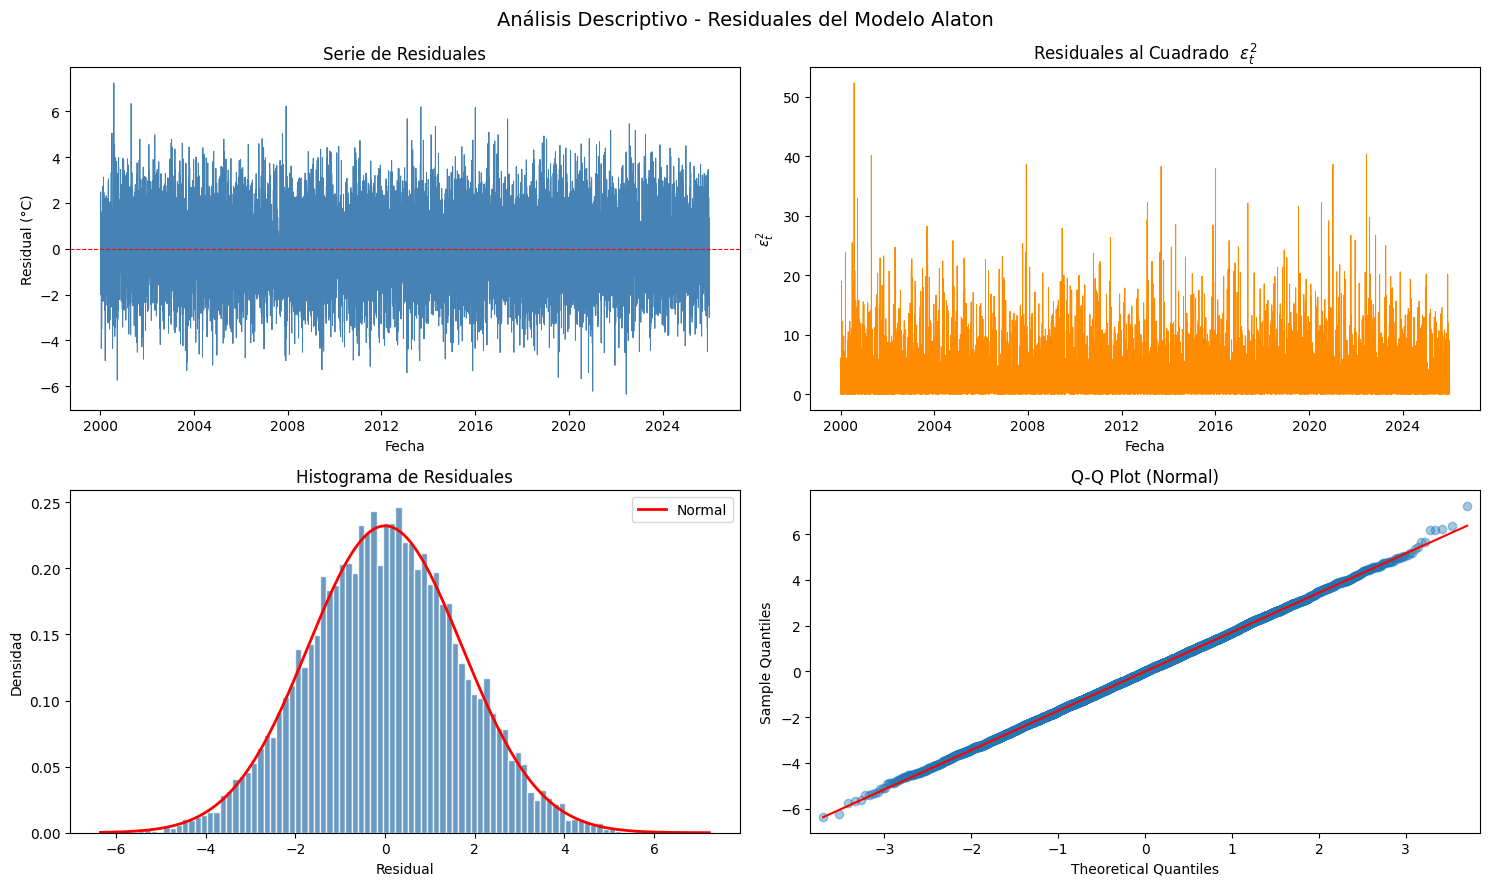

In [3]:
# =========================================================
# 3. VISUALIZACIÓN Y ESTADÍSTICAS DESCRIPTIVAS
# =========================================================

print("\n--- 3. ESTADÍSTICAS DESCRIPTIVAS DE RESIDUALES ---")
print(residuals.describe().round(4))

# Skewness y curtosis
from scipy.stats import skew, kurtosis
print(f"\nSkewness : {skew(residuals):.4f}")
print(f"Kurtosis : {kurtosis(residuals, fisher=False):.4f}  (Normal = 3)")

# Test de normalidad Jarque-Bera
jb_stat, jb_pval = jarque_bera(residuals)
print(f"\nJarque-Bera: Estadístico={jb_stat:.4f}, p-valor={jb_pval:.4f}")
if jb_pval < 0.05:
    print("→ Se rechaza normalidad (p < 0.05)")
else:
    print("→ No se rechaza normalidad (p ≥ 0.05)")

# --- Gráficas descriptivas ---
k = int(math.sqrt(len(residuals)))

fig, axes = plt.subplots(2, 2, figsize=(15, 9))
fig.suptitle('Análisis Descriptivo - Residuales del Modelo Alaton', fontsize=14)

# Serie temporal
axes[0, 0].plot(residuals.index, residuals, color='steelblue', linewidth=0.7)
axes[0, 0].axhline(0, color='red', linestyle='--', linewidth=0.8)
axes[0, 0].set_title('Serie de Residuales')
axes[0, 0].set_xlabel('Fecha')
axes[0, 0].set_ylabel('Residual (°C)')

# Residuales al cuadrado
axes[0, 1].plot(residuals.index, residuals**2, color='darkorange', linewidth=0.7)
axes[0, 1].set_title('Residuales al Cuadrado  $\\epsilon_t^2$')
axes[0, 1].set_xlabel('Fecha')
axes[0, 1].set_ylabel('$\\epsilon_t^2$')

# Histograma
axes[1, 0].hist(residuals, bins=k, color='steelblue', edgecolor='white', alpha=0.8, density=True)
x_range = np.linspace(residuals.min(), residuals.max(), 200)
axes[1, 0].plot(x_range,
                norm.pdf(x_range, residuals.mean(), residuals.std()),
                color='red', linewidth=2, label='Normal')
axes[1, 0].set_title('Histograma de Residuales')
axes[1, 0].set_xlabel('Residual')
axes[1, 0].set_ylabel('Densidad')
axes[1, 0].legend()

# Q-Q plot
sm.qqplot(residuals, line='s', ax=axes[1, 1], alpha=0.4)
axes[1, 1].set_title('Q-Q Plot (Normal)')

plt.tight_layout()
plt.savefig('../outputs/3_descriptive_residuals.png', dpi=150, bbox_inches='tight')
plt.show()

In [4]:
# =========================================================
# 4. TEST DE ESTACIONARIEDAD (ADF)
# =========================================================

print("\n--- 4. TEST DE ESTACIONARIEDAD (ADF) ---")

adf_result = adfuller(residuals, autolag='AIC')
print(f"\nADF Test sobre residuales:")
print(f"  Estadístico ADF : {adf_result[0]:.4f}")
print(f"  p-valor         : {adf_result[1]:.4f}")
print(f"  Lags utilizados : {adf_result[2]}")
print(f"  Obs. usadas     : {adf_result[3]}")
print("\n  Valores críticos:")
for key, val in adf_result[4].items():
    print(f"    {key}: {val:.4f}")

if adf_result[1] < 0.05:
    print("\n→ Serie ESTACIONARIA (p < 0.05) ✓")
else:
    print("\n→ Serie NO ESTACIONARIA (p ≥ 0.05) — considerar diferenciación")



--- 4. TEST DE ESTACIONARIEDAD (ADF) ---

ADF Test sobre residuales:
  Estadístico ADF : -98.6458
  p-valor         : 0.0000
  Lags utilizados : 0
  Obs. usadas     : 9496

  Valores críticos:
    1%: -3.4310
    5%: -2.8618
    10%: -2.5669

→ Serie ESTACIONARIA (p < 0.05) ✓


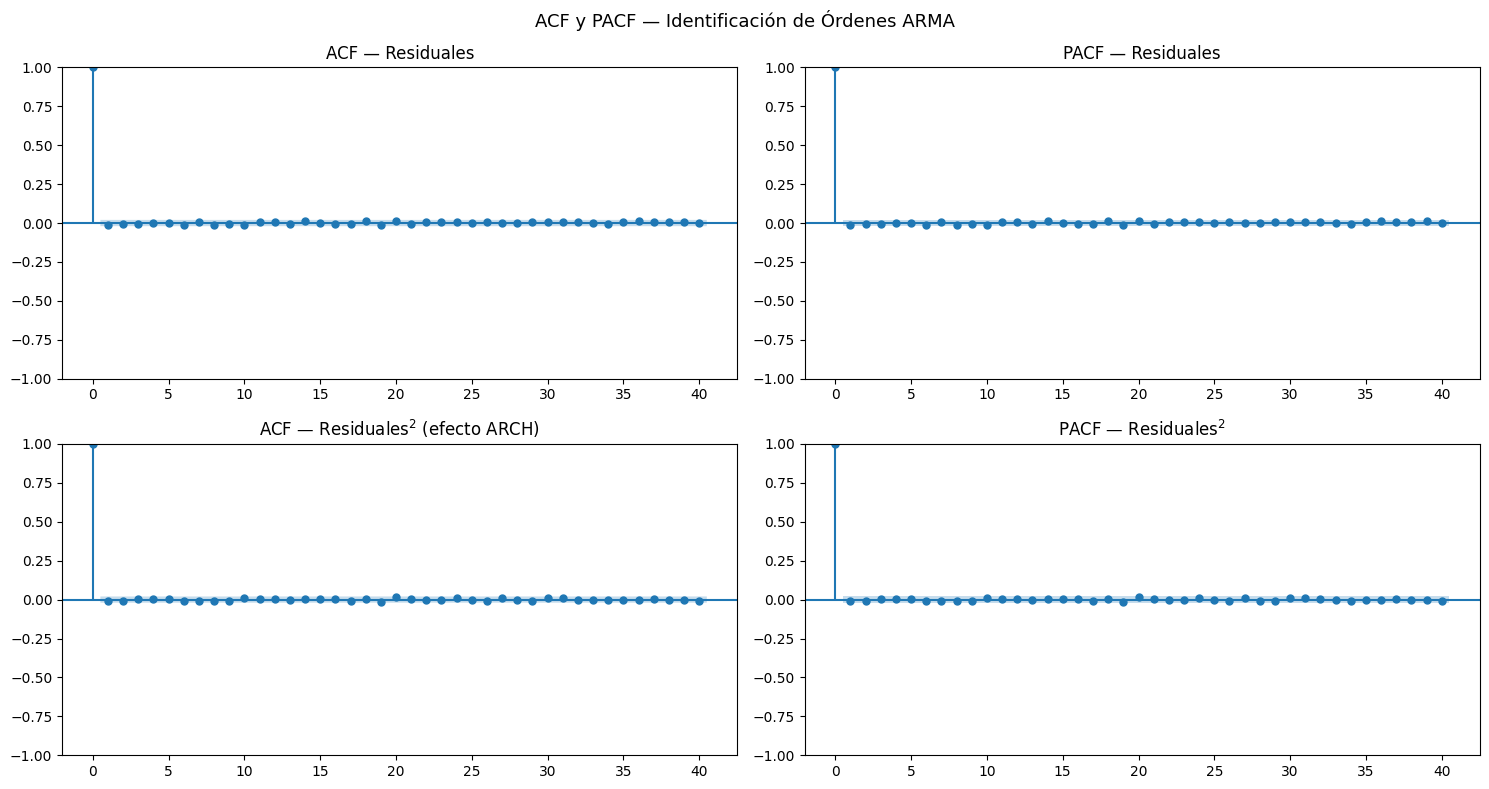

In [5]:
# =========================================================
# 5. ACF / PACF — IDENTIFICACIÓN DE ÓRDENES
# =========================================================

fig, axes = plt.subplots(2, 2, figsize=(15, 8))
fig.suptitle('ACF y PACF — Identificación de Órdenes ARMA', fontsize=13)

plot_acf(residuals, lags=40, ax=axes[0, 0], title='ACF — Residuales')
plot_pacf(residuals, lags=40, ax=axes[0, 1], title='PACF — Residuales',
          method='ywm')

plot_acf(residuals**2, lags=40, ax=axes[1, 0],
         title='ACF — Residuales$^2$ (efecto ARCH)')
plot_pacf(residuals**2, lags=40, ax=axes[1, 1],
          title='PACF — Residuales$^2$', method='ywm')

plt.tight_layout()
plt.savefig('../outputs/5_acf_pacf_residuals.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# =========================================================
# 6. SELECCIÓN DE ÓRDENES ÓPTIMOS ARMA(p,q) — AIC / BIC
# =========================================================

print("\n--- 6. SELECCIÓN DE ÓRDENES ARMA(p,q) VÍA AIC/BIC ---")

p_range = range(0, 5)   # AR: 0 a 4
q_range = range(0, 5)   # MA: 0 a 4

results_table = []

for p in p_range:
    for q in q_range:
        if p == 0 and q == 0:
            continue
        try:
            arma_fit = ARIMA(residuals, order=(p, 0, q)).fit()
            results_table.append({
                'p': p, 'q': q,
                'AIC': round(arma_fit.aic, 2),
                'BIC': round(arma_fit.bic, 2),
                'LogLik': round(arma_fit.llf, 2)
            })
        except Exception:
            continue

df_orders = pd.DataFrame(results_table).sort_values('AIC').reset_index(drop=True)

print("\nTop 10 combinaciones por AIC:")
print(df_orders.head(10).to_string(index=False))

# Órdenes óptimos
best_aic = df_orders.iloc[0]
best_bic = df_orders.sort_values('BIC').iloc[0]

p_opt = int(best_aic['p'])
q_opt = int(best_aic['q'])

print(f"\n→ Mejor por AIC : ARMA({p_opt},{q_opt})  "
      f"[AIC={best_aic['AIC']}]")
print(f"→ Mejor por BIC : ARMA({int(best_bic['p'])},{int(best_bic['q'])})  "
      f"[BIC={best_bic['BIC']}]")
print(f"\n→ Se usará ARMA({p_opt},{q_opt}) para el benchmark (criterio AIC)")



--- 6. SELECCIÓN DE ÓRDENES ARMA(p,q) VÍA AIC/BIC ---


c:\Users\jhoan\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\jhoan\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\jhoan\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\jhoan\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\jhoan\AppData\Local\Programs\Python\Python310\lib\s


Top 10 combinaciones por AIC:
 p  q      AIC      BIC    LogLik
 0  1 37243.64 37265.11 -18618.82
 1  0 37243.65 37265.13 -18618.83
 1  1 37244.86 37273.50 -18618.43
 0  2 37245.25 37273.89 -18618.63
 2  0 37245.27 37273.90 -18618.63
 0  3 37246.85 37282.64 -18618.42
 3  0 37246.85 37282.64 -18618.42
 1  2 37247.07 37282.86 -18618.53
 2  1 37247.26 37283.06 -18618.63
 0  4 37248.78 37291.74 -18618.39

→ Mejor por AIC : ARMA(0,1)  [AIC=37243.64]
→ Mejor por BIC : ARMA(0,1)  [BIC=37265.11]

→ Se usará ARMA(0,1) para el benchmark (criterio AIC)


In [7]:
# =========================================================
# 7. AJUSTE ARMA(p_opt, q_opt)
# =========================================================

print(f"\n--- 7. AJUSTE ARMA({p_opt},{q_opt}) ---")

arma_model = ARIMA(residuals, order=(p_opt, 0, q_opt)).fit()
print(arma_model.summary())

# Residuales del ARMA
arma_resid = arma_model.resid.dropna()



--- 7. AJUSTE ARMA(0,1) ---


c:\Users\jhoan\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\jhoan\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\jhoan\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:              residuals   No. Observations:                 9497
Model:                 ARIMA(0, 0, 1)   Log Likelihood              -18618.818
Date:                Fri, 22 May 2026   AIC                          37243.636
Time:                        22:28:21   BIC                          37265.112
Sample:                    01-01-2000   HQIC                         37250.924
                         - 12-31-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const      -4.491e-06      0.017     -0.000      1.000      -0.034       0.034
ma.L1         -0.0125      0.010     -1.209      0.227      -0.033       0.008
sigma2         2.9538      0.043     68.475      0.0

In [8]:
# =========================================================
# 8. TEST DE EFECTOS ARCH SOBRE RESIDUALES DEL ARMA
# =========================================================

print(f"\n--- 8. EFECTOS ARCH EN RESIDUALES ARMA({p_opt},{q_opt}) ---")

# 8.1 Ljung-Box sobre residuales al cuadrado
lb_result = acorr_ljungbox(arma_resid**2, lags=[5, 10, 20], return_df=True)
print("\nLjung-Box sobre residuales²:")
print(lb_result.round(4).to_string())

# 8.2 Test de Engle para efectos ARCH
arch_test = het_arch(arma_resid, nlags=10)
print(f"\nTest de Engle (ARCH LM):")
print(f"  Estadístico LM : {arch_test[0]:.4f}")
print(f"  p-valor        : {arch_test[1]:.4f}")
print(f"  Estadístico F  : {arch_test[2]:.4f}")
print(f"  p-valor F      : {arch_test[3]:.4f}")

if arch_test[1] < 0.05:
    print("\n→ Se confirman efectos ARCH (p < 0.05) ✓")
    print("→ Proceder con GARCH(1,1)")
else:
    print("\n→ No se evidencian efectos ARCH — el GARCH(1,1) se ajusta igualmente como benchmark")



--- 8. EFECTOS ARCH EN RESIDUALES ARMA(0,1) ---

Ljung-Box sobre residuales²:
    lb_stat  lb_pvalue
5    1.9424     0.8571
10   6.0664     0.8097
20  12.5982     0.8939

Test de Engle (ARCH LM):
  Estadístico LM : 6.1813
  p-valor        : 0.7998
  Estadístico F  : 0.6178
  p-valor F      : 0.8000

→ No se evidencian efectos ARCH — el GARCH(1,1) se ajusta igualmente como benchmark


In [9]:
# =========================================================
# 9. MODELO ARMA(p,q) — GARCH(1,1)
# =========================================================

print(f"\n--- 9. MODELO ARMA({p_opt},{q_opt})-GARCH(1,1) ---")

# La librería arch utiliza mean='AR' para el componente AR.
# Para ARMA completo: primero filtrar con ARMA statsmodels,
# luego pasar residuales al GARCH.
# Aquí usamos mean='ARX' con p_opt lags como benchmark estándar.

garch_model = arch_model(
    residuals,
    mean='AR',        # componente AR en la media
    lags=p_opt if p_opt > 0 else 1,
    vol='GARCH',
    p=1,
    q=1,
    dist='normal',
    rescale=False
)

garch_result = garch_model.fit(disp='off', show_warning=False)

print(garch_result.summary())

# Guardar parámetros
params_df = pd.DataFrame({
    'Parámetro': garch_result.params.index,
    'Estimación': garch_result.params.values.round(6),
    'Std Error': garch_result.std_err.values.round(6),
    't-stat': garch_result.tvalues.values.round(4),
    'p-valor': garch_result.pvalues.values.round(4)
})

print("\nParámetros del modelo:")
print(params_df.to_string(index=False))

# Verificar restricción estacionariedad: alpha + beta < 1
alpha_params = [v for k, v in garch_result.params.items() if 'alpha' in k]
beta_params  = [v for k, v in garch_result.params.items() if 'beta'  in k]

if alpha_params and beta_params:
    persist = sum(alpha_params) + sum(beta_params)
    print(f"\nPersistencia (α + β) = {persist:.4f}")
    if persist < 1:
        print("→ Proceso de varianza ESTACIONARIO (α + β < 1) ✓")
    else:
        print("→ ADVERTENCIA: proceso integrado (α + β ≥ 1)")



--- 9. MODELO ARMA(0,1)-GARCH(1,1) ---
                           AR - GARCH Model Results                           
Dep. Variable:              residuals   R-squared:                       0.000
Mean Model:                        AR   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -18616.7
Distribution:                  Normal   AIC:                           37243.3
Method:            Maximum Likelihood   BIC:                           37279.1
                                        No. Observations:                 9496
Date:                Fri, May 22 2026   Df Residuals:                     9494
Time:                        22:28:22   Df Model:                            2
                                   Mean Model                                   
                    coef    std err          t      P>|t|       95.0% Conf. Int.
--------------------------------------------------------------------------------
Const 


--- 10. DIAGNÓSTICOS DE RESIDUALES ESTANDARIZADOS ---

Jarque-Bera residuales std: Estadístico=1.7204, p-valor=0.4231

Ljung-Box residuales std (media):
    lb_stat  lb_pvalue
5    0.8595     0.9731
10   5.0588     0.8872
20  11.3761     0.9359

Ljung-Box residuales std² (varianza):
    lb_stat  lb_pvalue
5    2.0205     0.8463
10   6.3072     0.7888
20  12.7923     0.8861


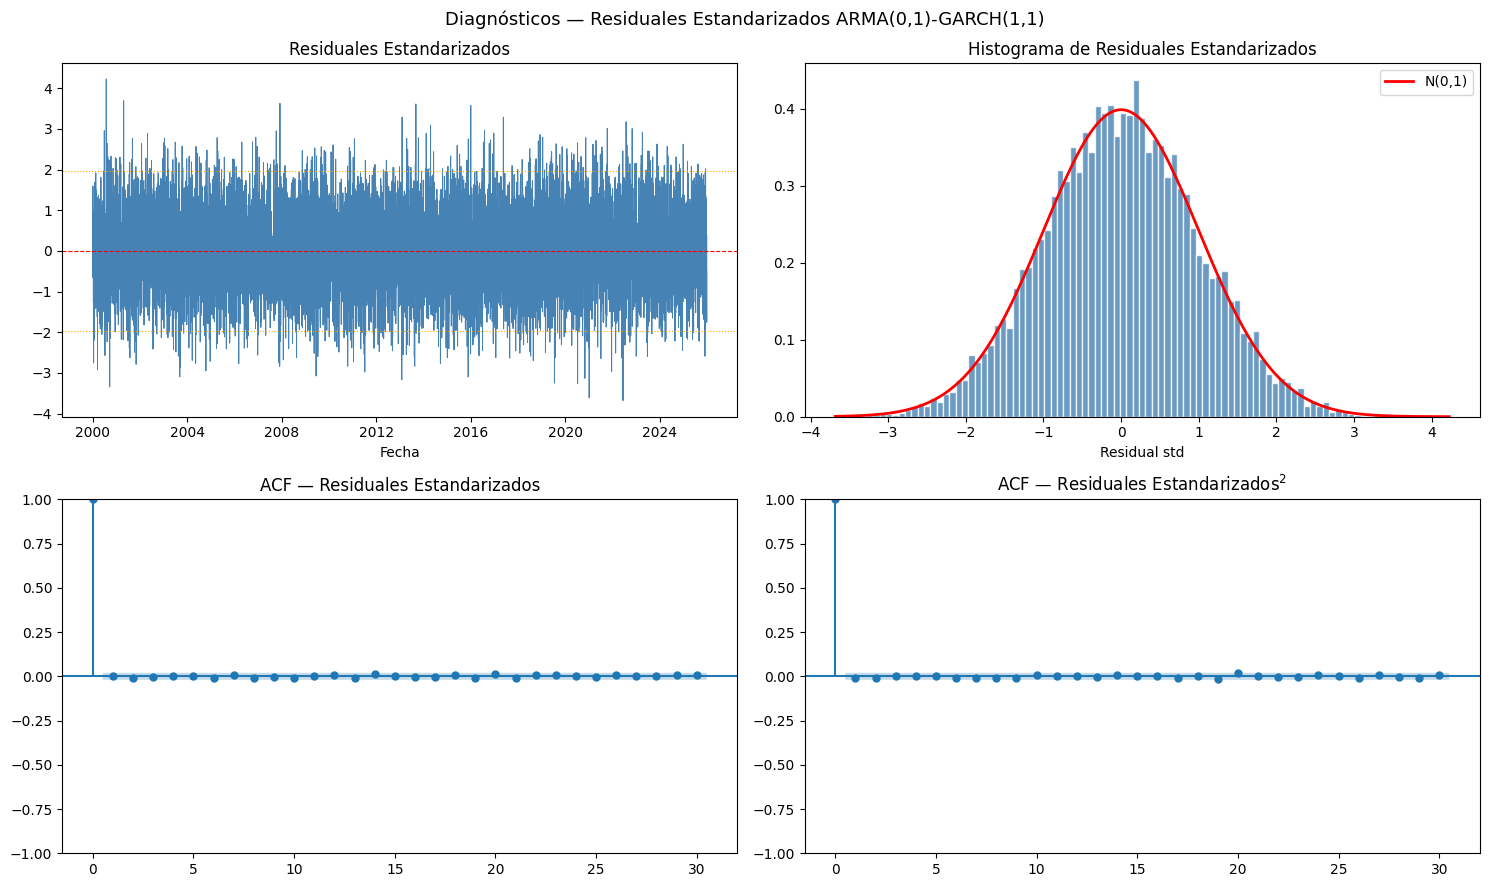

In [10]:
# =========================================================
# 10. DIAGNÓSTICOS DE RESIDUALES ESTANDARIZADOS
# =========================================================

print("\n--- 10. DIAGNÓSTICOS DE RESIDUALES ESTANDARIZADOS ---")

std_resid = garch_result.std_resid.dropna()

# Estadísticas
jb_g, jb_g_p = jarque_bera(std_resid)
print(f"\nJarque-Bera residuales std: Estadístico={jb_g:.4f}, p-valor={jb_g_p:.4f}")

lb_std = acorr_ljungbox(std_resid, lags=[5, 10, 20], return_df=True)
print("\nLjung-Box residuales std (media):")
print(lb_std.round(4).to_string())

lb_std2 = acorr_ljungbox(std_resid**2, lags=[5, 10, 20], return_df=True)
print("\nLjung-Box residuales std² (varianza):")
print(lb_std2.round(4).to_string())

# Gráficas diagnóstico
k = int(math.sqrt(len(std_resid)))

fig, axes = plt.subplots(2, 2, figsize=(15, 9))
fig.suptitle(f'Diagnósticos — Residuales Estandarizados ARMA({p_opt},{q_opt})-GARCH(1,1)',
             fontsize=13)

# Serie residuales std
axes[0, 0].plot(std_resid.index, std_resid, color='steelblue', linewidth=0.7)
axes[0, 0].axhline(0, color='red', linestyle='--', linewidth=0.8)
axes[0, 0].axhline(1.96, color='orange', linestyle=':', linewidth=0.8)
axes[0, 0].axhline(-1.96, color='orange', linestyle=':', linewidth=0.8)
axes[0, 0].set_title('Residuales Estandarizados')
axes[0, 0].set_xlabel('Fecha')

# Histograma
axes[0, 1].hist(std_resid, bins=k, color='steelblue', edgecolor='white',
                alpha=0.8, density=True)
x_r = np.linspace(std_resid.min(), std_resid.max(), 200)
axes[0, 1].plot(x_r, norm.pdf(x_r, 0, 1), color='red', linewidth=2, label='N(0,1)')
axes[0, 1].set_title('Histograma de Residuales Estandarizados')
axes[0, 1].set_xlabel('Residual std')
axes[0, 1].legend()

# ACF residuales std
plot_acf(std_resid, lags=30, ax=axes[1, 0],
         title='ACF — Residuales Estandarizados')

# ACF residuales std²
plot_acf(std_resid**2, lags=30, ax=axes[1, 1],
         title='ACF — Residuales Estandarizados$^2$')

plt.tight_layout()
plt.savefig('../outputs/10_diagnostics_garch.png', dpi=150, bbox_inches='tight')
plt.show()



--- 11. VOLATILIDAD CONDICIONAL ---

Volatilidad condicional promedio : 1.7190 °C
Volatilidad condicional máxima  : 1.7209 °C
Volatilidad condicional mínima  : 1.5561 °C


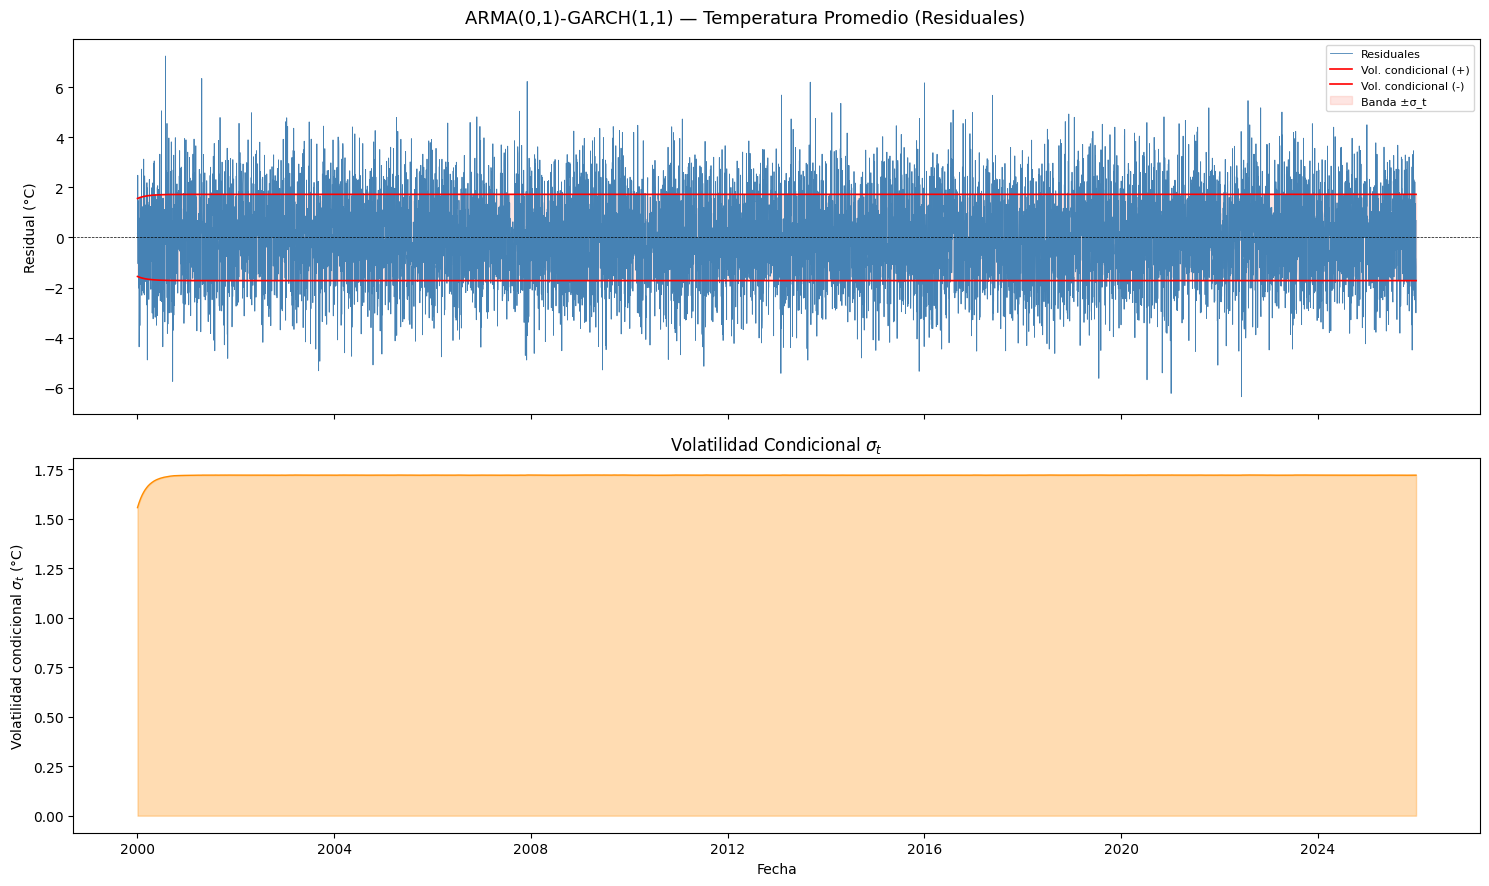

In [11]:
# =========================================================
# 11. VOLATILIDAD CONDICIONAL
# =========================================================

print("\n--- 11. VOLATILIDAD CONDICIONAL ---")

cond_vol = garch_result.conditional_volatility

vol_mean = cond_vol.mean()
vol_max  = cond_vol.max()
vol_min  = cond_vol.min()
print(f"\nVolatilidad condicional promedio : {vol_mean:.4f} °C")
print(f"Volatilidad condicional máxima  : {vol_max:.4f} °C")
print(f"Volatilidad condicional mínima  : {vol_min:.4f} °C")

# Gráfica de volatilidad condicional
fig, axes = plt.subplots(2, 1, figsize=(15, 9), sharex=True)
fig.suptitle(f'ARMA({p_opt},{q_opt})-GARCH(1,1) — Temperatura Promedio (Residuales)',
             fontsize=13)

axes[0].plot(residuals.index, residuals, color='steelblue', linewidth=0.6,
             label='Residuales')
axes[0].plot(cond_vol.index,  cond_vol,  color='red',
             linewidth=1.2, label='Vol. condicional (+)')
axes[0].plot(cond_vol.index, -cond_vol, color='red',
             linewidth=1.2, label='Vol. condicional (-)')
axes[0].fill_between(cond_vol.index, -cond_vol, cond_vol,
                     color='salmon', alpha=0.2, label='Banda ±σ_t')
axes[0].axhline(0, color='black', linestyle='--', linewidth=0.5)
axes[0].set_ylabel('Residual (°C)')
axes[0].legend(loc='upper right', fontsize=8)

axes[1].plot(cond_vol.index, cond_vol, color='darkorange', linewidth=1.0)
axes[1].fill_between(cond_vol.index, 0, cond_vol, color='darkorange', alpha=0.3)
axes[1].set_ylabel('Volatilidad condicional $\\sigma_t$ (°C)')
axes[1].set_xlabel('Fecha')
axes[1].set_title('Volatilidad Condicional $\\sigma_t$')

plt.tight_layout()
plt.savefig('../outputs/11_conditional_volatility.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# =========================================================
# 12. PRONÓSTICO 1 PASO ADELANTE
# =========================================================

print("\n--- 12. PRONÓSTICO 1 PASO ADELANTE ---")

forecast = garch_result.forecast(horizon=1)
vol_forecast = np.sqrt(forecast.variance.values[-1, 0])
mean_forecast = forecast.mean.values[-1, 0]

print(f"\nPronóstico media (residual)   : {mean_forecast:.4f} °C")
print(f"Pronóstico volatilidad (σ_t+1): {vol_forecast:.4f} °C")
print(f"Intervalo 95%: [{mean_forecast - 1.96*vol_forecast:.4f}, "
      f"{mean_forecast + 1.96*vol_forecast:.4f}] °C")


--- 12. PRONÓSTICO 1 PASO ADELANTE ---

Pronóstico media (residual)   : -0.0086 °C
Pronóstico volatilidad (σ_t+1): 1.7201 °C
Intervalo 95%: [-3.3800, 3.3628] °C


In [13]:
# =========================================================
# 13. RESUMEN EJECUTIVO
# =========================================================

print("\n" + "=" * 60)
print("RESUMEN EJECUTIVO — BENCHMARK ARMA-GARCH")
print("=" * 60)
print(f"\nModelo ajustado : ARMA({p_opt},{q_opt})-GARCH(1,1)")
print(f"Serie           : Residuales del modelo Alaton (T_avg)")
print(f"Observaciones   : {len(residuals)}")
print(f"\nCriterios de información del GARCH:")
print(f"  AIC : {garch_result.aic:.4f}")
print(f"  BIC : {garch_result.bic:.4f}")
print(f"\nParámetros GARCH:")
for name, val in garch_result.params.items():
    pval = garch_result.pvalues[name]
    sig  = '***' if pval < 0.01 else ('**' if pval < 0.05 else ('*' if pval < 0.10 else ''))
    print(f"  {name:<20} {val:>10.6f}  (p={pval:.4f}) {sig}")

if alpha_params and beta_params:
    print(f"\nPersistencia (α+β) : {persist:.4f}")
print(f"Vol. condicional final : {cond_vol.iloc[-1]:.4f} °C")
print(f"Pronóstico σ_(t+1)     : {vol_forecast:.4f} °C")
print("\n" + "=" * 60)


RESUMEN EJECUTIVO — BENCHMARK ARMA-GARCH

Modelo ajustado : ARMA(0,1)-GARCH(1,1)
Serie           : Residuales del modelo Alaton (T_avg)
Observaciones   : 9497

Criterios de información del GARCH:
  AIC : 37243.3051
  BIC : 37279.0982

Parámetros GARCH:
  Const                 -0.000219  (p=0.9901) 
  residuals[1]          -0.012351  (p=0.2260) 
  omega                  0.039975  (p=0.0011) ***
  alpha[1]               0.000032  (p=0.9842) 
  beta[1]                0.986459  (p=0.0000) ***

Persistencia (α+β) : 0.9865
Vol. condicional final : 1.7201 °C
Pronóstico σ_(t+1)     : 1.7201 °C

